# **Tugas Ekstraksi Fitur - Computer Vision**
**Nama : Fadhli Ilham Nafi'an Yuswono**

**NIM : 2318001**

Import Library & connect ke Google Drive

In [10]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

# Menyambungkan ke Google Drive
drive.mount('/content/drive')
print("✅ Google Drive berhasil tersambung! 📁")

folder_path = '/content/drive/MyDrive/Study/Semester 6/Computer Vision/Tugas Ekstraksi Fitur/10 Citra'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive berhasil tersambung! 📁


Menampilkan Citra dari Google Drive


FOTO CITRA


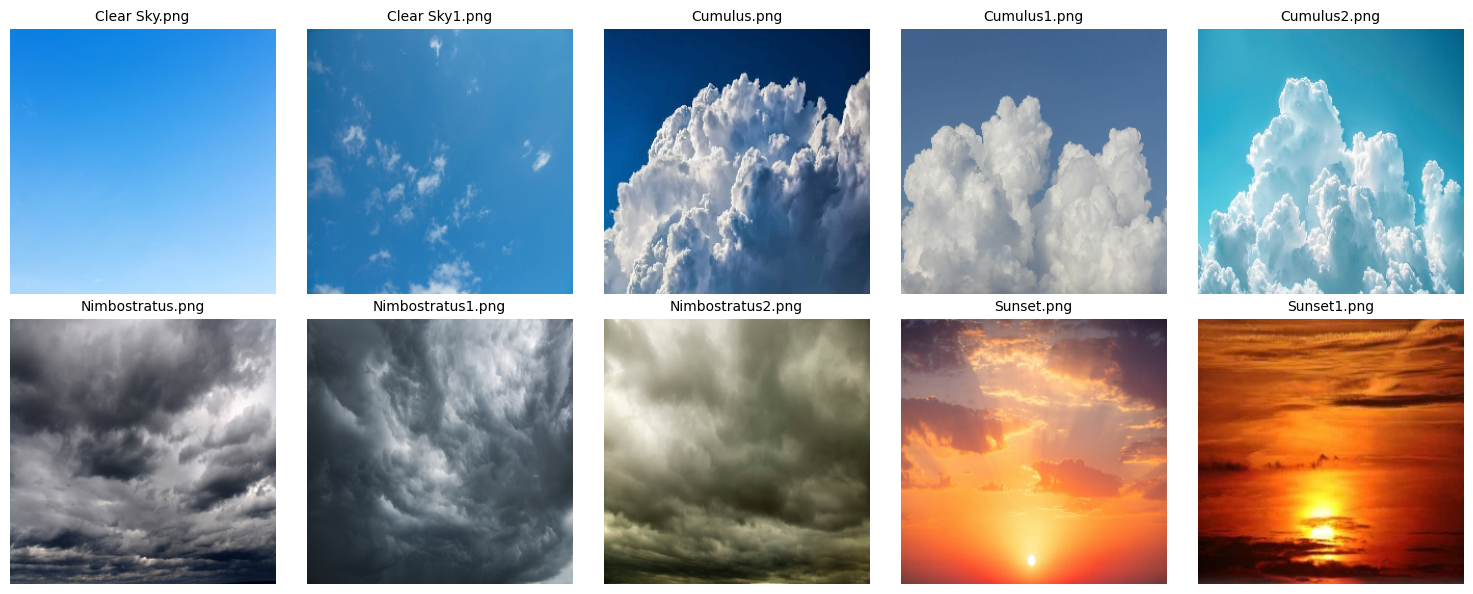

In [15]:
plt.figure(figsize=(15, 6))
print("\nFOTO CITRA")

idx = 1
# u/ membaca gambar secara berurutan
for filename in sorted(os.listdir(folder_path)):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path) #read citra

        if img is not None:
            # convert BGR ke RGB agar warna normal saat ditampilkan
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if idx <= 10:
                plt.subplot(2, 5, idx)
                plt.imshow(img_rgb)
                plt.title(filename, fontsize=10)
                plt.axis('off')
                idx += 1

plt.tight_layout()
plt.show()

Proses Ekstraksi Fitur Rata-Rata Warna RGB

In [12]:
# Buat list kosong u/ menyimpan nilai fitur warna dan nama file
features = []
image_names = []

for filename in sorted(os.listdir(folder_path)):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        img = cv2.imread(os.path.join(folder_path, filename))

        if img is not None:
            # Ekstraksi rata2 warna (Blue=0, Green=1, Red=2)
            mean_b = np.mean(img[:,:,0])
            mean_g = np.mean(img[:,:,1])
            mean_r = np.mean(img[:,:,2])

            # Gabungkan fitur warna ke dalam list
            color_feature = [mean_r, mean_g, mean_b]
            features.append(color_feature)

            # Tambahkan nama file citra ke dalam list
            image_names.append(filename)
print(f"✨Ekstraksi fitur RGB seelsai, total {len(image_names)} citra! 🎨")

✨Ekstraksi fitur RGB seelsai, total 10 citra! 🎨


Pembuatan Tabel Klasifikasi & Export ke CSV

In [17]:
# konversi list fitur warna dan nama file citra menjadi numpy array
features = np.array(features)
image_names = np.array(image_names)

# membuat DataFrame dari numpy array fitur warna dan nama file citra
df = pd.DataFrame({
    'Nama File': image_names,
    'Mean R': features[:,0],
    'Mean G': features[:,1],
    'Mean B': features[:,2]
})

# Menghitung fitur Cahaya dan Rasio Warna
df['Total RGB'] = df['Mean R'] + df['Mean G'] + df['Mean B']
df['Ratio R/B'] = df['Mean R'] / df['Mean B']

# Fungsi untuk menebak cuaca dari komposisi warnanya
def klasifikasi(row):
    # Senja : Merah dominan banget dibanding biru karena efek matahari terbenam
    if row['Ratio R/B'] >= 1.5:
        return 'Senja'

    # Mendung (Nimbostratus) : Warnanya keabu-abuan (merah & biru hampir seimbang) dan kelihatan gelap
    elif row['Ratio R/B'] >= 0.81 and row['Total RGB'] < 400:
        return 'Mendung'

    # Cerah (Clear Sky) : Biru menang telak, nilai merahnya sangat rendah
    elif row['Ratio R/B'] < 0.45:
        return 'Langit Cerah'

    # Berawan (Cumulus) : Sisa dari tebakan di atas (awan putih biasa yang cerah)
    else:
        return 'Berawan'

# Menerapkan fungsi ke setiap baris tabel
df['Prediksi Cuaca'] = df.apply(klasifikasi, axis=1)
print("\n📊 HASIL TABEL EKSTRAKSI & KLASIFIKASI 📈")
df.index = df.index + 1
display(df)

csv_output = '/content/drive/MyDrive/Study/Semester 6/Computer Vision/Tugas Ekstraksi Fitur/2318001FadhliHasilEktraksiFitur.csv'
df.to_csv(csv_output, index=False)
print(f"\n✅ File CSV berhasil disimpan!\n📂 Lokasi : {csv_output} 📊")


📊 HASIL TABEL EKSTRAKSI & KLASIFIKASI 📈


,Nama File,Mean R,Mean G,Mean B,Total RGB,Ratio R/B,Prediksi Cuaca
1,Clear Sky.png,93.537338,175.786087,242.097153,511.420578,0.386363,Langit Cerah
2,Clear Sky1.png,57.858658,131.948822,185.647232,375.454712,0.311659,Langit Cerah
3,Cumulus.png,84.498779,112.622833,144.415817,341.537430,0.585108,Berawan
4,Cumulus1.png,136.568604,151.723892,168.792221,457.084717,0.809093,Berawan
5,Cumulus2.png,107.340866,179.594238,201.261108,488.196213,0.533341,Berawan
6,Nimbostratus.png,114.162613,115.188599,122.460236,351.811447,0.932242,Mendung
7,Nimbostratus1.png,92.443130,103.789230,112.615662,308.848022,0.820873,Mendung
8,Nimbostratus2.png,123.380402,121.655609,98.827606,343.863617,1.248441,Mendung
9,Sunset.png,206.369629,133.090988,91.124512,430.585129,2.264699,Senja
10,Sunset1.png,169.386902,73.849289,19.840027,263.076218,8.537635,Senja



✅ File CSV berhasil disimpan!
📂 Lokasi : /content/drive/MyDrive/Study/Semester 6/Computer Vision/Tugas Ekstraksi Fitur/2318001FadhliHasilEktraksiFitur.csv 📊
